# "Portuguese Bank Marketing Prediction "

**Problem Statement**
This project uses data from a Portuguese bank's telemarketing campaigns (2008–2010), aimed at promoting term deposits.

Objectives:

Analyze customer and campaign data.

Build a model to predict if a client will subscribe to a term deposit.

Suggest ways to improve campaign success.

# 1. Importing libraries 

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

## 2. Loading a Dataset

In [5]:
df = pd.read_csv("bank-full.csv",sep=";")

In [6]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## 3. Exploratory Data Analysis

In [7]:
# Check for null values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


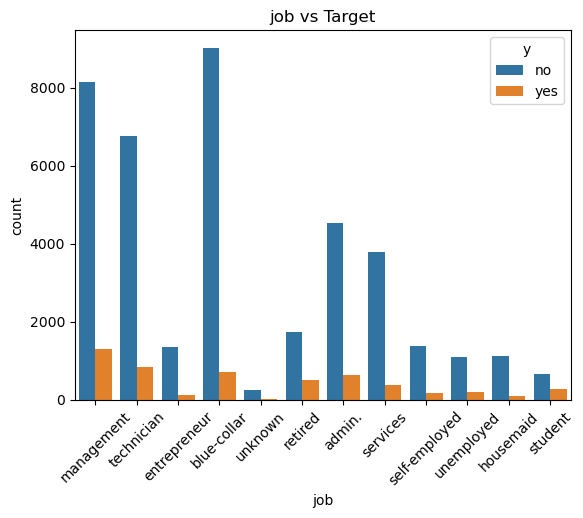

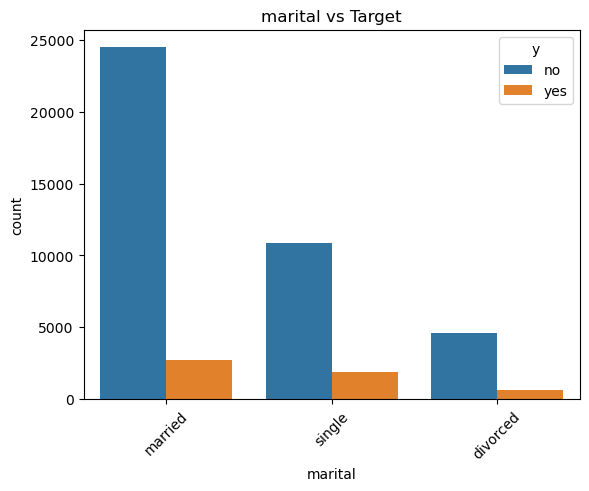

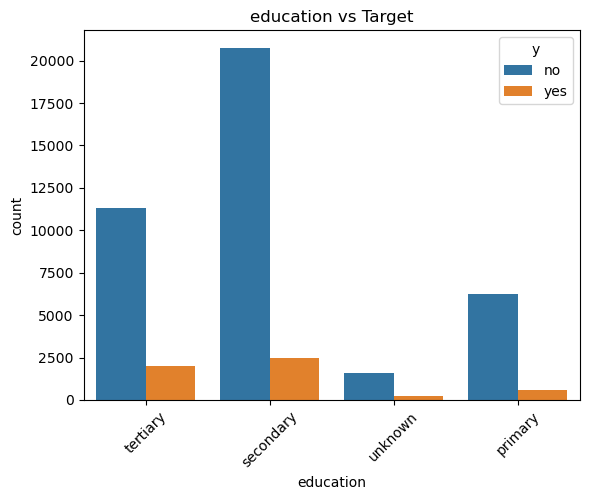

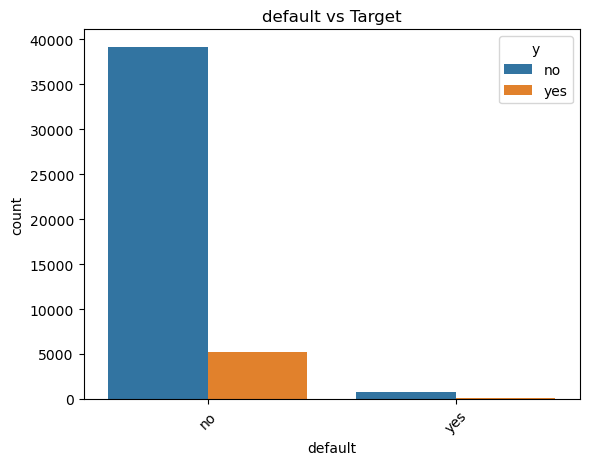

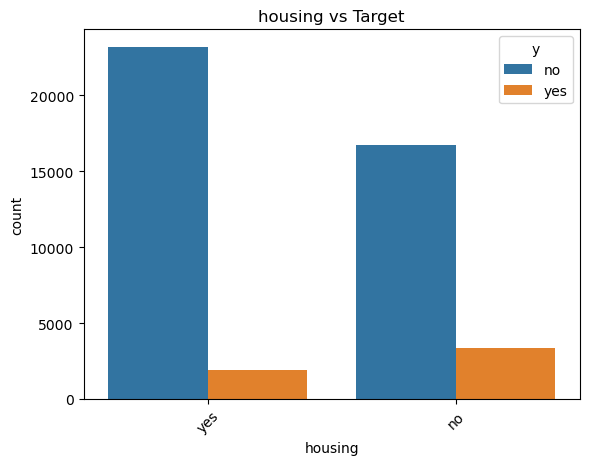

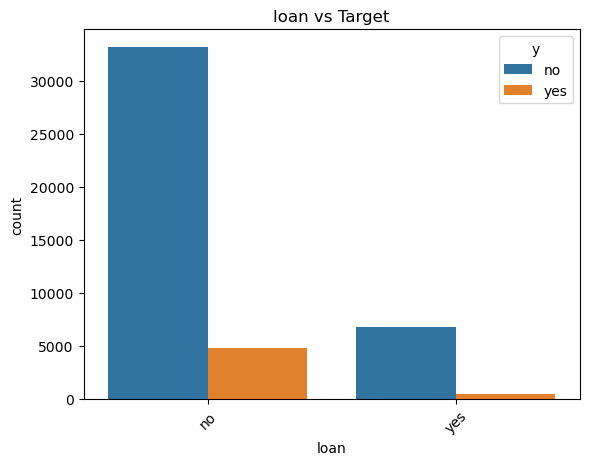

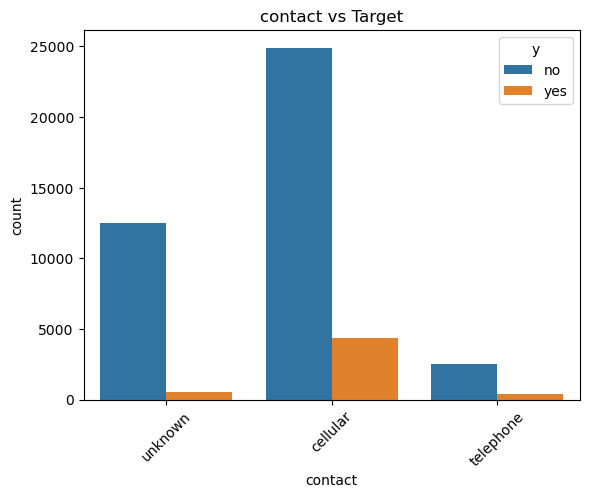

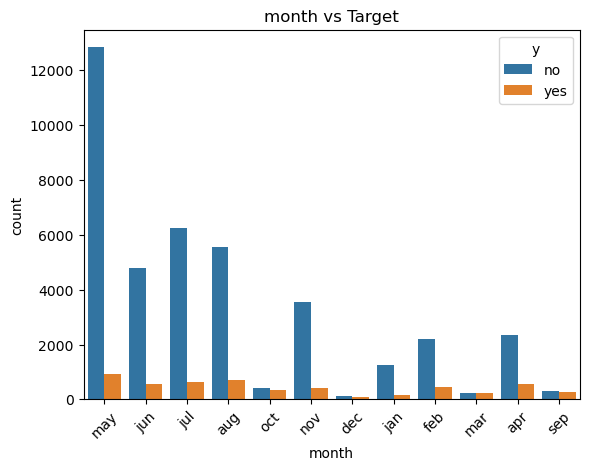

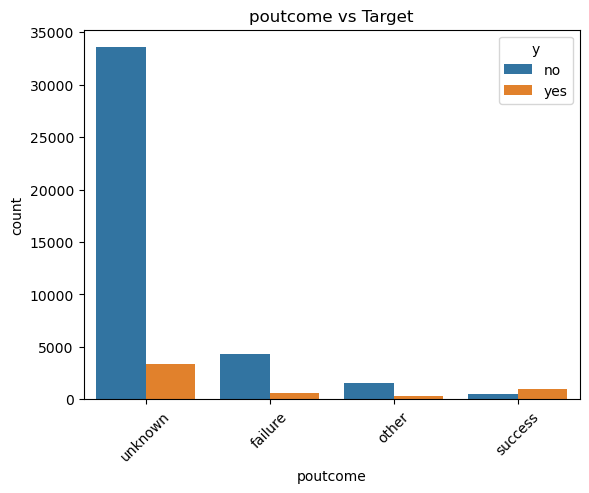

In [12]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
for col in categorical_cols:
    sns.countplot(data=df, x=col, hue='y')
    plt.title(f'{col} vs Target')
    plt.xticks(rotation=45)
    plt.show()

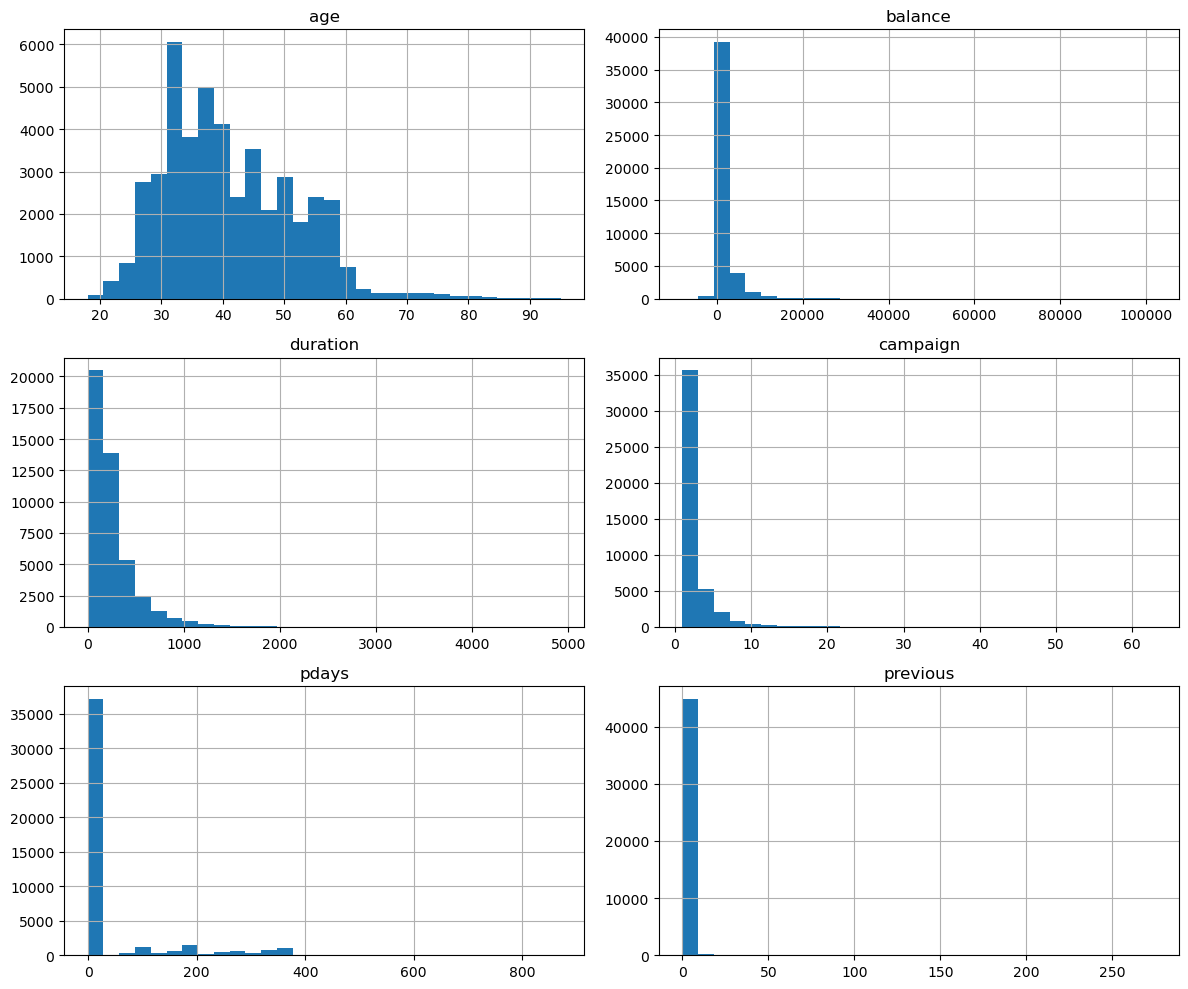

In [13]:
numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
df[numeric_cols].hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

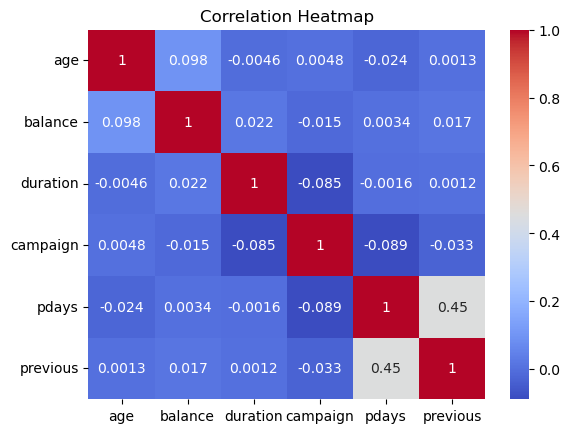

In [16]:
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


### **Key Insights**

#### **Demographics & Client Behavior**
- Most customers are between **30–40 years**, suggesting the bank’s campaigns mainly reach working-age individuals.  
- **Married clients** dominate the dataset, but **single clients** tend to subscribe slightly more often.  
- **Education** strongly influences response — clients with **tertiary education** have higher subscription rates.

#### **Contact & Campaign Factors**
- **Telephone (cellular)** contact methods perform better than traditional ones.  
- **Longer campaign duration** correlates negatively with success — too many calls reduce conversion likelihood.  
- **Previous outcomes** of campaigns affect current success; those with previous success respond better.

#### **Economic Context**
- When the **employment variation rate** and **euribor3m** (interest rate) are **low**, people are more likely to subscribe — meaning favorable economic conditions encourage term deposits.

#### **Overall Patterns**
- The dataset is **imbalanced** — most responses are “no”.  
- Feature importance likely includes **duration**, **poutcome**, and **contact type**.


## 4. Data Preprocessing

In [14]:
# Encode categorical variables using LabelEncoder
label_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0


In [17]:
# Feature-target split

X = df.drop("y", axis=1)  # Features
y = df["y"]               # Target


In [18]:
# train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [19]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
# Handling class imbalance (SMOTE / class_weight)

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


## 5. Training and Building Predictive models

### 1. Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced', C=0.5, solver='saga')
log_reg.fit(X_train_scaled, y_train)  # You can skip SMOTE if using class_weight

LogisticRegression(C=0.5, class_weight='balanced', max_iter=5000,
                   random_state=42, solver='saga')

### 2. Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### 3. XGBoost

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'   # keep this
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

### 5. Predictions

In [24]:
# Logistic Regression (scaled)
y_pred_log = log_reg.predict(X_test_scaled) 
# Random Forest
y_pred_rf = rf.predict(X_test) 
# XGBoost
y_pred_xgb = xgb.predict(X_test)             

In [25]:
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression Evaluation
print(" Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("-"*60)

# Random Forest Evaluation
print(" Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("-"*60)

# XGBoost Evaluation
print(" XGBoost")
print("Accuracy:", accuracy_score(y_test,y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test,y_pred_xgb))
print("-"*60)

 Logistic Regression
Accuracy: 0.8043790777396882

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.80      0.88      7952
           1       0.36      0.81      0.50      1091

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.89      0.80      0.83      9043

------------------------------------------------------------
 Random Forest
Accuracy: 0.9004755059161783

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.64      0.41      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043

------------------------------------------------------------
 XGBoost
Accuracy: 0.9056728961627778

Classification Report:
               pre

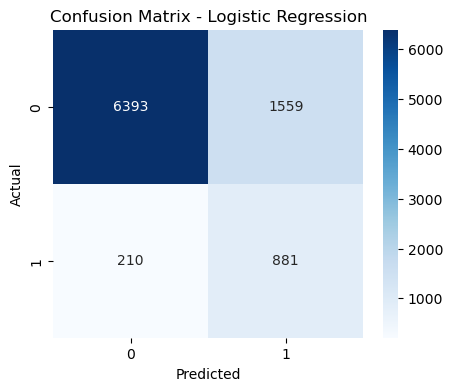

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix - Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

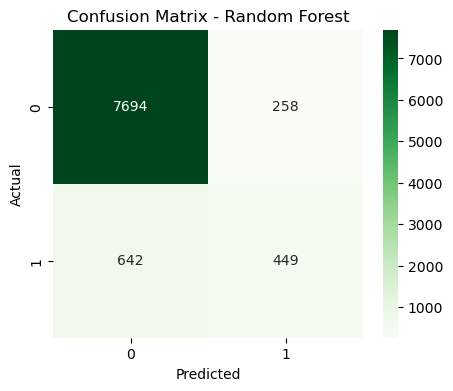

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


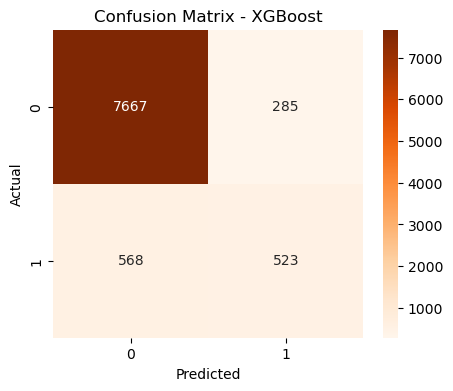

In [28]:
# Confusion Matrix - XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

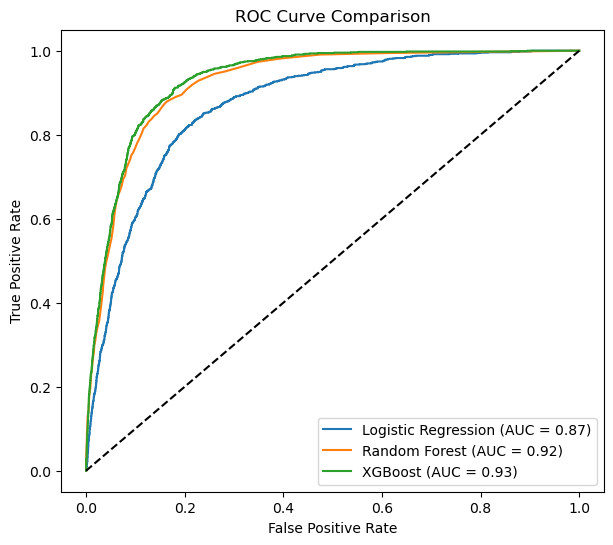

In [29]:
# AUC and ROC

from sklearn.metrics import roc_curve, auc

# Logistic Regression (scaled test set)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)


# Random Forest (unscaled test set)
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost (unscaled test set)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)



# Plot ROC Curves
plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot([0,1], [0,1], 'k--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [30]:
# Model Comparison Table

from sklearn.metrics import accuracy_score, f1_score

# Collect metrics
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  F1 Score
0  Logistic Regression  0.804379  0.499009
1        Random Forest  0.900476  0.499444
2              XGBoost  0.905673  0.550816


## 6. Conclusion

Among the three models tested:
- Logistic Regression achieved an AUC of 0.87  
- Random Forest achieved an AUC of 0.92  
- XGBoost achieved the best performance with an AUC of 0.93  

Therefore, **XGBoost is the recommended model** for predicting customer subscription in the Portuguese Bank Marketing dataset, due to its higher discriminative power and overall performance.